# Project guidé de segmentation des vaisseaux

- A faire en monome ou binôme (pas plus de 2 étudiants)
- Indiquez NOM-prénom des 1 ou 2 personnes impliquées 
- La soumission doit se faire sur EDUNAO

Hugues Talbot Février 2025

In [2]:
## La bonne façon d'installer cv2, à ne réaliser que si besoin

!pip3 uninstall opencv-contrib-python opencv-python
!pip3 install opencv-contrib-python
!pip3 install imagecodecs

In [2]:
## Ne pas executer à l'intérieur de Visual Studio Code
# %matplotlib notebook
## A l'intérieur de Google Colab, utiliser plutôt
# %matplotlib inline

# Projet guidé, segmentation de vaisseaux sanguins

Les vaisseaux sanguins sont très difficiles à identifier et segmenter sur des images car se sont des objets "fins" : ils ont une orientation locale privilégiée, et deviennent généralement plus petit en diamètre que la résolution du capteur. Ils disparaissent donc progressivement dans le bruit de celui-ci.

L'objectif de ce projet est de realiser une segmentation d'images de vaisseaux de fond d'oeil avec des performances acceptables par des moyens classiques, y compris la morphologie mathématique.

In [14]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import skimage
import cv2
import imageio.v2 as iio
import imagecodecs

from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
### To help viewing images

## to view a single image
def imview(image, cmap="gray", interpolation="nearest", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap, interpolation=interpolation)
    plt.axis("off")
    plt.show()


## to view several images at once
def viewlist(images, cmap="gray", figsize=(18, 6)):
    plt.figure(figsize=(24, 8))
    columns = len(images)
    for i, image in enumerate(images):
        plt.subplot(1, columns, i + 1)
        plt.imshow(image, cmap=cmap)
        plt.axis("off")
    plt.show()

### Vaisseaux rétiniens

Les images de fond d'oeil sont acquises en routine chez les ophtalmologues à chaque visite. On peut y déceler de nombreuses pathologies, celles affectant la rétine mais aussi d'autres telles l'hypertension arterielle ou le diabète, même à un stade peu développé. C'est une des rares modalités où il est relativement facile de déceler les vaisseaux capillaires.

On utilise ici une petite base de donnée de 20 images. L'illustration des méthodes se fait sur l'une d'entre elles mais vous devez faire tourner vos methodes sur les 20 images. La base comprend les images de fond d'oeil, un masque de la zone d'acquisition et un masque binaire des vaisseaux segmentés à la main par un spécialiste. On cherche à s'approcher de la qualité de la segmentation manuelle.

Même dans le cas où on souhaiterait utiliser une approche par apprentissage, il est essentiel de réaliser une normalisation des images pour éviter les variations de couleur, illumination, niveau de bruit intenpestifs.

Voici une stratégie générale:

- Trouver le masque de la zone d'acquisition, car en pratique clinique, celui-ci n'est pas donné. 
- Rehausser l'apparence des vaisseaux, avec par exemple un filtre médian et/ou un top-hat noir (voir ci-dessous) 
- Réduire le bruit sans détruire les vaisseaux. Des filtres connectifs pourraient être utiles.
- Trouver un seuillage automatique
- Optimiser les paramètres de ces approches pour s'approcher le plus possible du résultat de segmentation manuel.

Essayez vos stratégiques sur 1-3 images, testez sur la base toute entière de 20 images.

In [8]:
## Lecture d'une image
img1 = iio.imread("Eye_fundus/images/21_training.tif")
## masque d'acquisition
gtmask1 = iio.imread("Eye_fundus/mask/21_training_mask.gif")
## annotation manuelle du masque des vaisseaux. Notez qu'il n'est pas parfait mais vous allez vous rendre compte que c'est difficile de s'en approcher.
manual1 = iio.imread("Eye_fundus/1st_manual/21_manual1.gif")

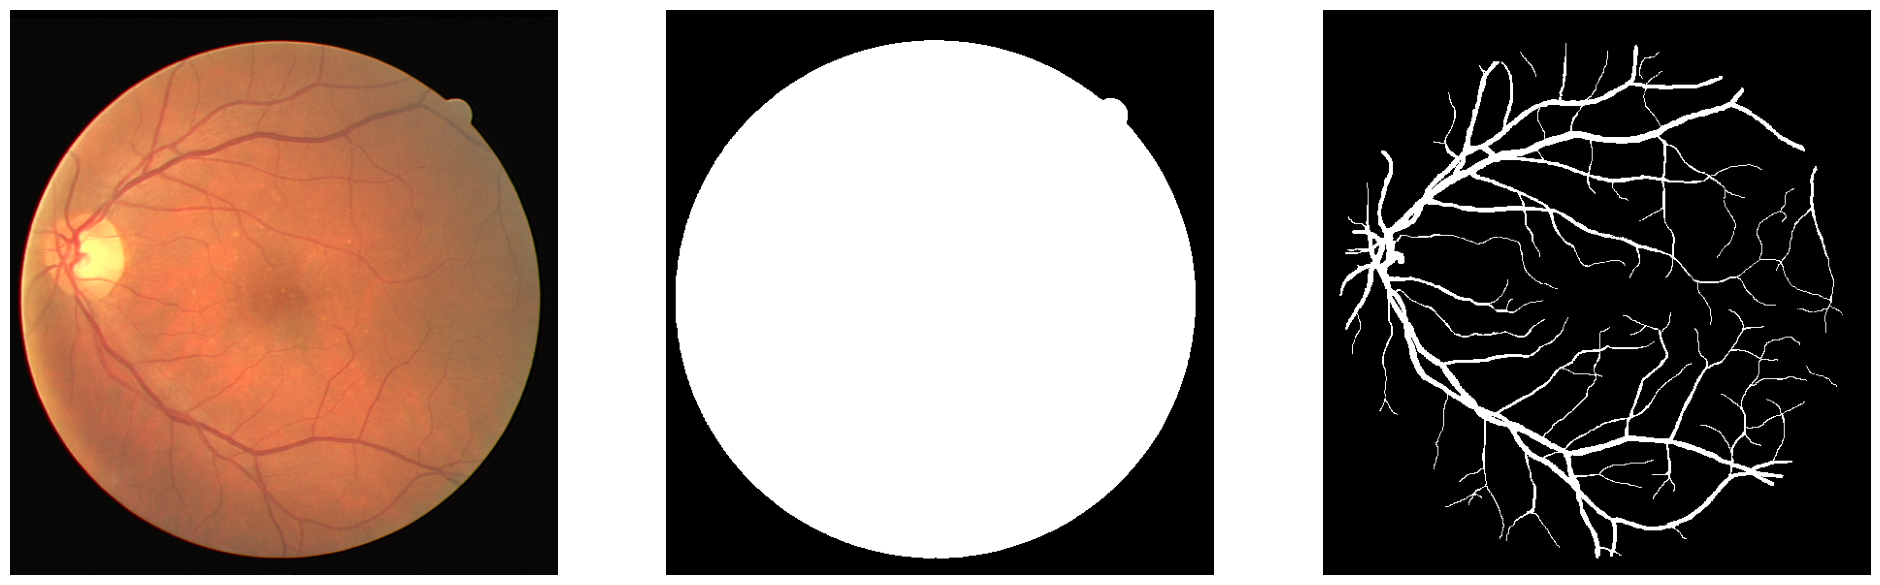

In [ ]:
viewlist((img1, gtmask1, manual1))

## 1- Segmentation du masque binaire

Ça devrait être assez facile car le contraste est assez net....

Min =  0.0 Max =  0.9703117647058824


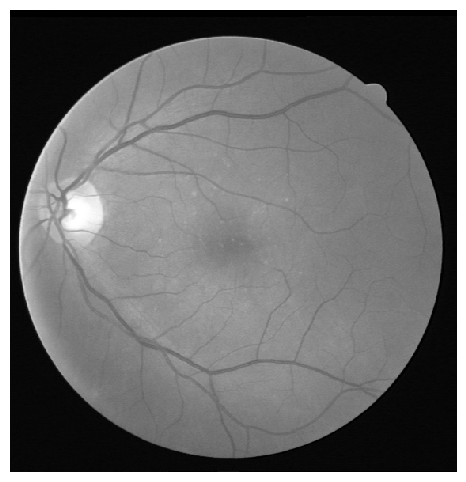

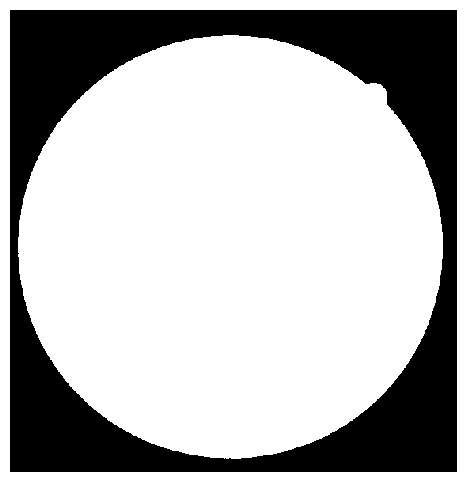

In [10]:
# Conversion en niveaux de gris
from skimage.color import rgb2gray

imgg1 = rgb2gray(img1)
print("Min = ", np.min(imgg1), "Max = ", np.max(imgg1))

imview(imgg1)


binmask1 = imgg1 > 0.1
imview(binmask1)

## Mesure de la qualité de la segmentation

La qualité d'une segmentation est souvent donnée par la pseudo-métrique de Dice, qui vaut 0 si une segmentation de référence et celle proposée n'ont rien en commun, et 1 si elles sont identiques.

Cette métrique est la même que la métrique F1 d'une matrice de confusion.

$$ 
\begin{matrix}
                & \text{True} & \text{False} \\
\text{Positive} &     TP      & FP           \\
\text{Negative} &     FN      & TN           \\
\end{matrix}
$$

Les vérité de terrain sont en colonne et les estimations en ligne

Le score F1 ou la métrique de Dice sont données par la formule
$$
Dice(A,B) = \frac{2 TP}{TP+FP+FN}
$$

On note que les vrais négatifs ne sont pas utilisés. C'est normal, car dans une segmentation le plus souvent le fond est beaucoup plus grand que la forme en surface. Utiliser les vrais négatifs dans une mesure de précision par exemple donnerait des résultats faussement optimistes.

In [ ]:
def dice(im1, im2):
    """
    Computes the Dice coefficient, a measure of set similarity.
    Parameters
    ----------
    im1 : array-like, bool
        Any array of arbitrary size. If not boolean, will be converted.
    im2 : array-like, bool
        Any other array of identical size. If not boolean, will be converted.
    Returns
    -------
    dice : float
        Dice coefficient as a float on range [0,1].
        Maximum similarity = 1
        No similarity = 0

    Notes
    -----
    The order of inputs for `dice` is irrelevant. The result will be
    identical if `im1` and `im2` are switched.
    """
    im1 = np.asarray(im1).astype(bool)
    im2 = np.asarray(im2).astype(bool)

    if im1.shape != im2.shape:
        raise ValueError("Shape mismatch: im1 and im2 must have the same shape.")

    # Compute Dice coefficient
    intersection = np.logical_and(im1, im2)

    return 2.0 * intersection.sum() / (im1.sum() + im2.sum())

In [ ]:
## Qualité de la segmentation réalisée

print("Quality of the mask segmentation:", dice(gtmask1, binmask1))

## anything over 99% is pretty much indistinguishable from the ground truth

Quality of the mask segmentation: 0.9982320490949775


## Question 1 : vérifier et si nécessaire améliorez la qualité de la segmentation du masque sur toute la base de donnée

Reportez le Dice moyen

In [ ]:
img_folder = Path("Eye_fundus/images")
gt_folder = Path("Eye_fundus/mask")

dice_scores = []

for img_path in img_folder.glob("*.tif"):
    gt_path = gt_folder / (img_path.stem + "_mask.gif")
    img = iio.imread(img_path)
    img = rgb2gray(img)
    gtmask = iio.imread(gt_path)
    binmask = img > 0.1

    dice_scores.append(dice(gtmask, binmask))

print("Average Dice score across the dataset:", np.mean(dice_scores))

Average Dice score across the dataset: 0.9962719131472764


<blockquote>

**Puisque nos résultats excèdent déjà un Dice de 0.99, la méthode de segmentation du masque est considérée comme satisfaisante. Dans un autre contexte, nous aurions pu inclure en supplément une étape de post-traitement en enlevant les petits objets du masque, en appliquant une fermeture morphologique pour combler les trous, ou en utilisant des techniques de seuillage adaptatif.**

</blockquote>

## 2- Preprocessing de l'image de fond d'oeil

On pourra utiliser le masque segmenter pour réduire les effets de bord.

Première idée simple: un top-hat noir. D'après le cours de morphologie mathématique, une fermerture $\varphi_B$ avec un élément structurant $B$ est extensive.
On calcule $BTH$ de la façon suivante

$$
BTH(I) = \varphi_B(I) - I
$$

Ce résidu est donc une image positive

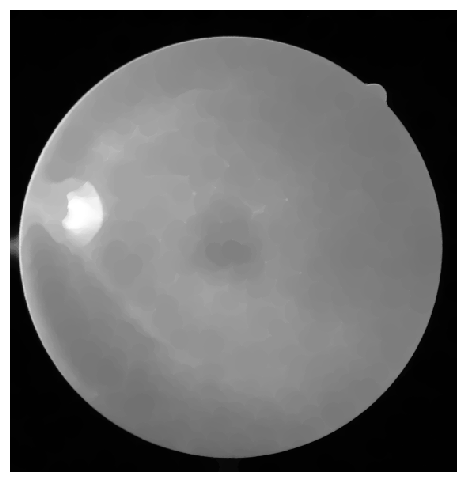

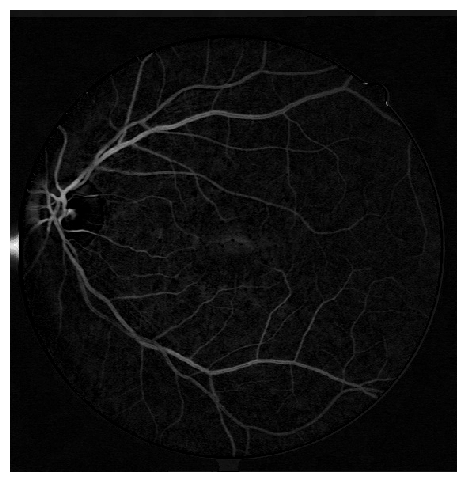

In [19]:
from skimage.morphology import closing, disk

imgclo1 = closing(imgg1, disk(11))

imview(imgclo1)

## black top hat

bth1 = imgclo1 - imgg1
imview(bth1)

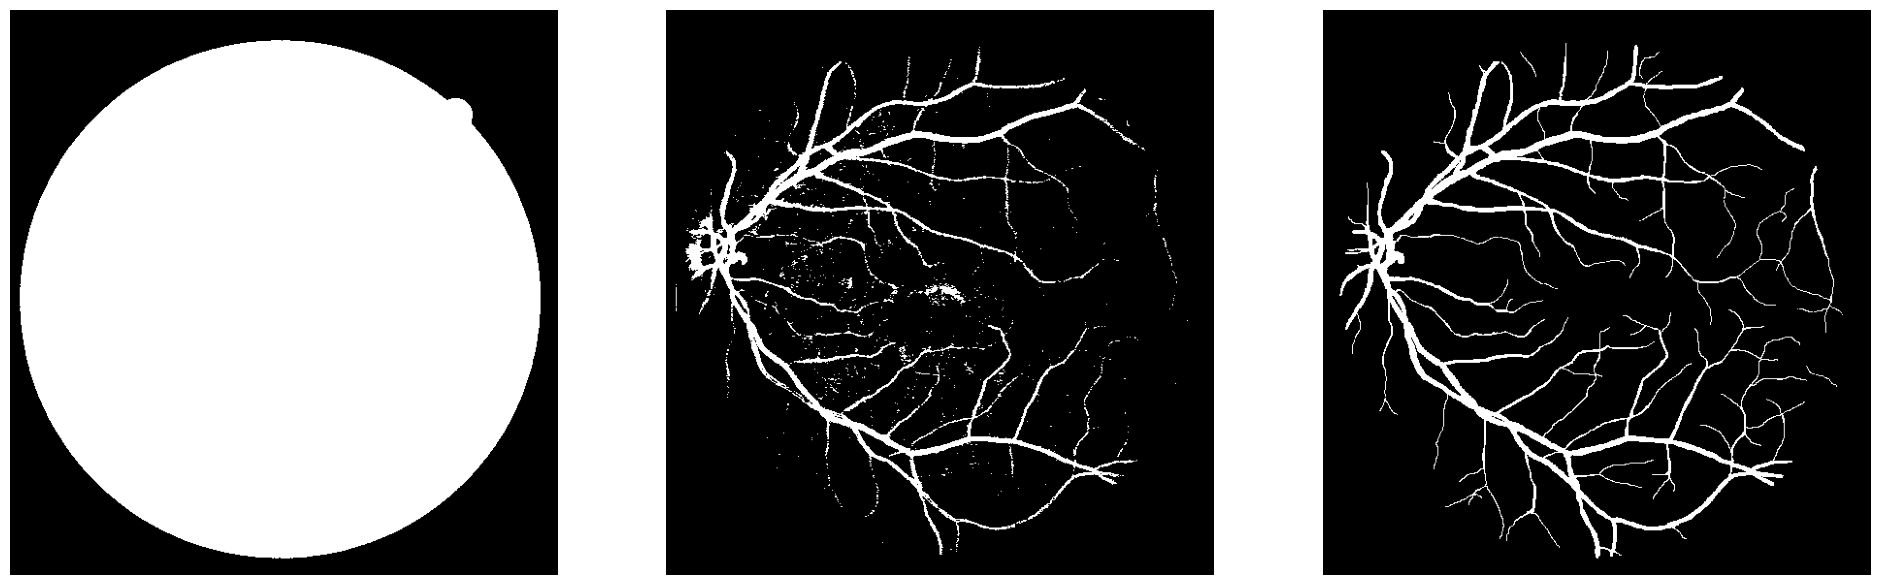

In [ ]:
## Seuillage simpliste

vessels1 = (bth1 > 0.05) * binmask1
viewlist((binmask1, vessels1, manual1))

In [21]:
## Mesure des performances de cette approche

print("Vessel segmentation quality", dice(manual1, vessels1))


Vessel segmentation quality 0.7408264021705289


## Question 2: automatiser et faire tourner cette approche sur la base de 20 images

Le seuillage est manuel, mais un seuillage automatique serait sans doute meilleur. 

voir par exemple [cette page](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_thresholding.html), qui fait partie de la documentation de Scikit-image

Rapportez le Dice moyen.

In [ ]:
img_folder = Path("Eye_fundus/images")
gt_folder = Path("Eye_fundus/1st_manual")

dice_scores = []

for img_path in img_folder.glob("*.tif"):
    gt_path = gt_folder / (img_path.stem.replace("training", "manual1") + ".gif")
    img = iio.imread(img_path)
    img = rgb2gray(img)
    gt = iio.imread(gt_path)

    img_clo = closing(img, disk(11))
    bth = img_clo - img

    binmask = img > 0.1
    threshold = skimage.filters.threshold_otsu(bth[binmask])
    vessels = (bth > threshold) * binmask

    dice_scores.append(dice(gt, vessels))

print("Average Dice score across the dataset:", np.mean(dice_scores))

Average Dice score across the dataset: 0.6155412291472143


<blockquote>

**Nous avons obtenu un Dice moyen de 0.64 en utilisant un top-hat noir suivi d'un seuillage automatique avec la méthode de Otsu. Bien que ce résultat soit un bon point de départ, il y a encore une marge d'amélioration significative. Nous pourrions envisager une méthode de seuillage local, des étapes de pré-traitement pour augmenter le contraste des images, de post-traitement pour éliminer les petits objets ou combler les trous, ou même utiliser le canal vert de l'image qui est souvent plus informatif pour les vaisseaux.**

</blockquote>

## 3- Optionnel: améliorer votre score

Les questions 1 et 2 sont les seules obligatoires. En option, vous pouvez tenter d'améliorer votre score moyen

### Annexe: commentaires et pistes d'améliorations possibles

Vous pouvez tenter tout ou partie des approches suivantes:

- Try to optimize the parameters of the approach, maybe on half the database, test on the other half
    - The diameter of the disk
    - The threshold
    - Try to improve the mask, it may help

- Try some connective approach, under the assuption that the vessel network is connected, using **higra**
- Try using a well-researched gradient instead or before the top hat, eg the Dollar gradient (see `cv2.ximgproc.createStructuredEdgeDetection` from `higra_tutoria_01`)
- Try using some denoising and image simplification
- Try using the *Vesselness* filters from scikit-image, [especially designed to enhance vessels](https://scikit-image.org/docs/stable/api/skimage.filters.html). 
    - Try the Frangi filter and 
    - Try the Sato tubeness enhancement.
    They both require some parameter tuning
    
- Try using directional closings with a family of segment as structuring elements (must be done by hand)
- Try [RORPO](https://www.ipol.im/pub/art/2017/207/) from Ipol (Image Processing On Line), ideally download the C code and turn it into a Python package.
- Take a critical approach to the metric. Is Dice the best metric? Are the annotation of good enough quality ?
- Combine some or all of these approaches...

- Compare with a learning-based approach, deep or otherwise. Example of DL approaches [Khanal A, Estrada R. Dynamic deep networks for retinal vessel segmentation. Frontiers in Computer Science. 2020:35.](https://arxiv.org/abs/1903.07803)

### 3.1- Trying some denoising

In [ ]:
from skimage.morphology import area_opening, area_closing


def mmdenoise(img, iter, clofirst=True):
    imgi = img.copy()
    for i in range(1, iter):
        if clofirst:
            imgc = area_closing(imgi, i)
            imgo = area_opening(imgc, i)
            imgi = imgo
        else:
            imgo = area_opening(imgi, i)
            imgc = area_closing(imgo, i)
            imgi = imgc
        print(".", end="")
    return imgi

In [ ]:
imgg1d = mmdenoise(imgg1, 8, clofirst=False)

.......

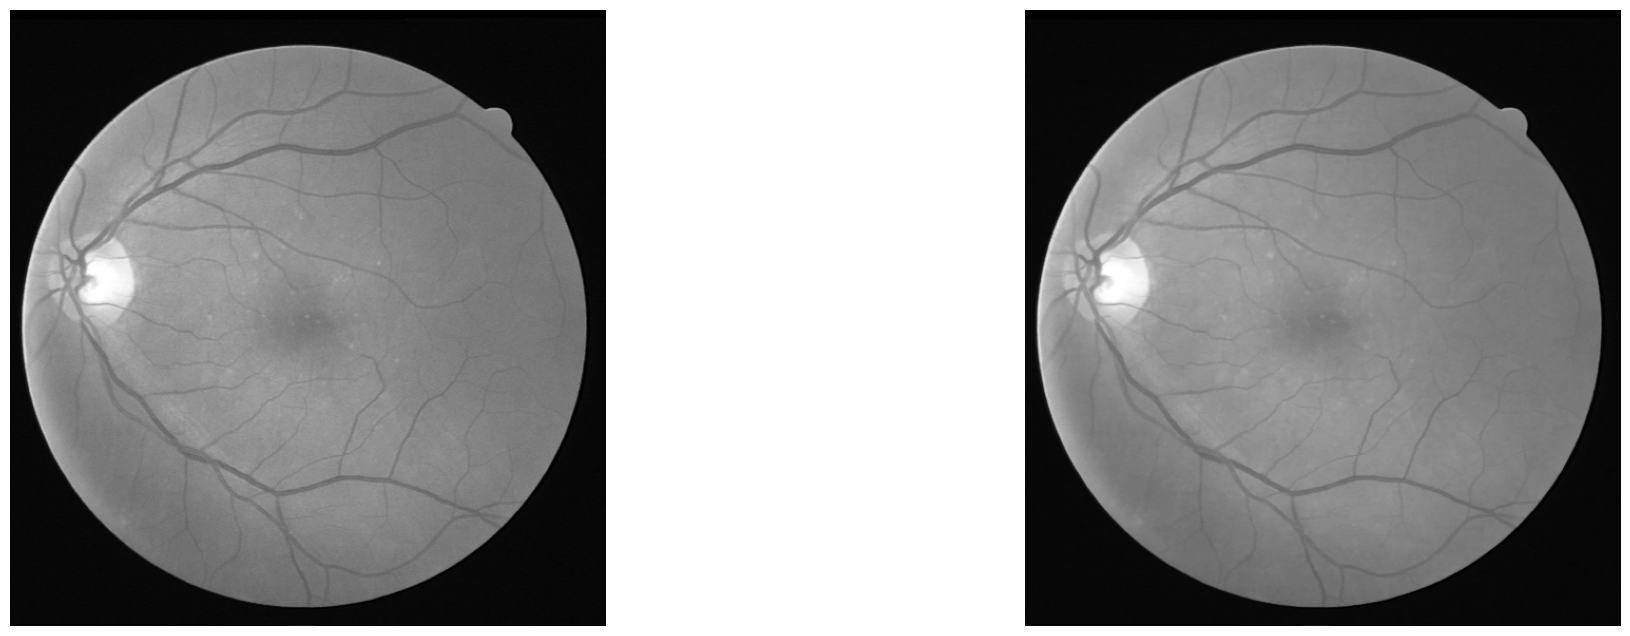

In [ ]:
viewlist((imgg1, imgg1d))

In [ ]:
def simpleseg(fundus, mask, diameter, threshold):
    imgclo1 = closing(fundus, disk(diameter))
    bth1 = (imgclo1 - fundus) >= threshold
    return bth1 * mask

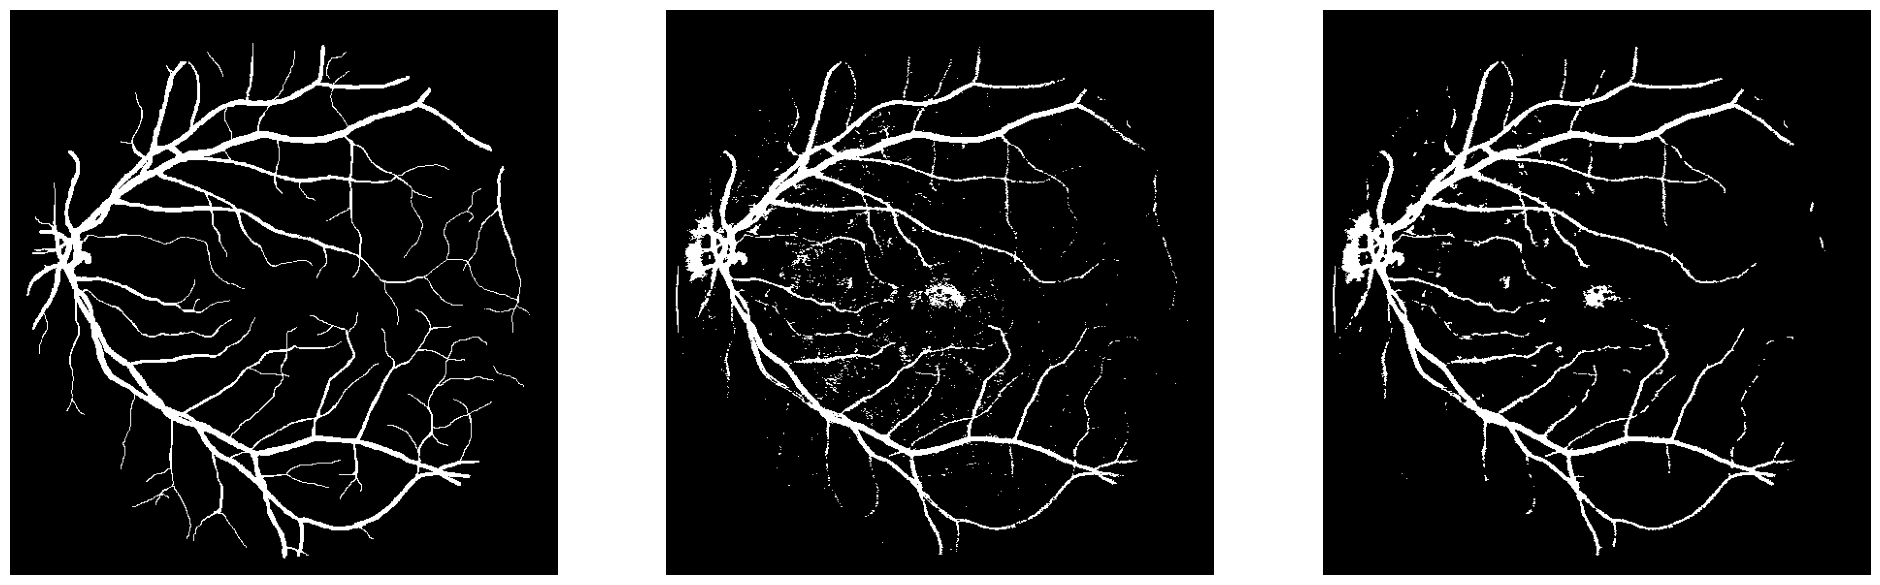

In [ ]:
ss1 = simpleseg(imgg1, binmask1, 13, 0.05)
ssd1 = simpleseg(imgg1d, binmask1, 13, 0.035)  ## with denoising, we can threshold lower
viewlist((manual1, ss1, ssd1))

In [ ]:
print("Simple segmentation not denoise score =", dice(manual1, ss1))
print("Simple segmentation, denoised.  score =", dice(manual1, ssd1))

Simple segmentation not denoise score = 0.7272068384813797
Simple segmentation, denoised.  score = 0.7515434097483055


Denoising seems to help. You can try various denoising methods available in scikit image, look in particular to Non-local means

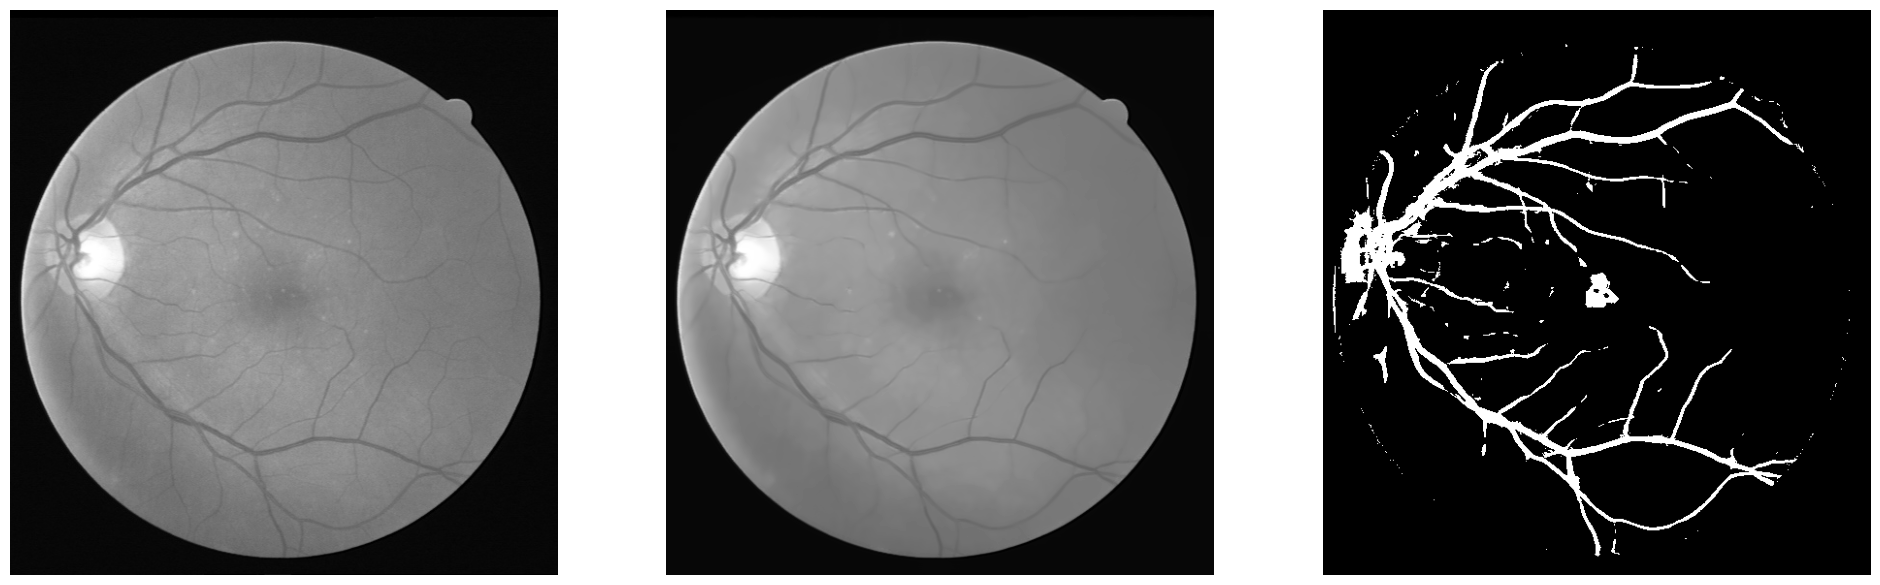

Score of the non-local-means denoising method=  0.7226974503778756


In [ ]:
from skimage.restoration import denoise_nl_means

imgg1nld = denoise_nl_means(
    imgg1, patch_size=9, h=0.01, patch_distance=22, preserve_range=True
)  ## it is worth it to explore the parameters of this method

ssnld1 = simpleseg(imgg1nld, binmask1, 13, 0.02)

viewlist((imgg1, imgg1nld, ssnld1))

print("Score of the non-local-means denoising method= ", dice(manual1, ssnld1))

## 3.2- Using a learned gradient

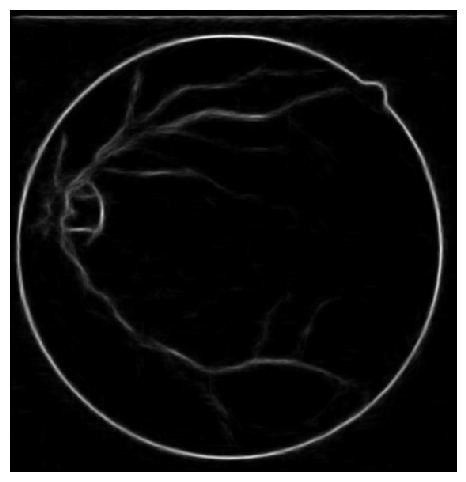

In [ ]:
import higra as hg
import cv2


import urllib.request as request

exec(
    request.urlopen(
        "https://github.com/higra/Higra-Notebooks/raw/master/utils.py"
    ).read(),
    globals(),
)


detector = cv2.ximgproc.createStructuredEdgeDetection(get_sed_model_file())

img1f = img1.astype(np.float32) / 255  ## for this we use the colour image as input

gradient_image = detector.detectEdges(img1f)

imview(gradient_image)

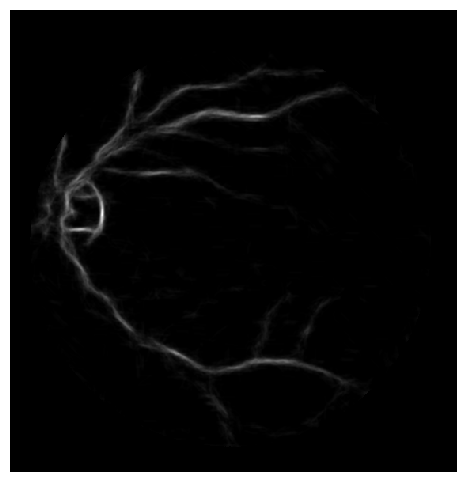

In [ ]:
## we need to use a shrunk mask

from skimage.morphology import erosion, opening

smask1 = erosion(binmask1, disk(15))

gradvessel1 = gradient_image * smask1
imview(gradvessel1)

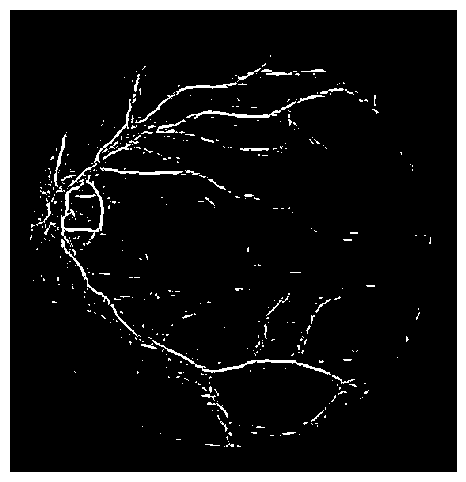

In [ ]:
## use a white top-hat on the gradient

gradvesseld1 = gradvessel1 - opening(gradvessel1, disk(2)) > 0.01
imview(gradvesseld1)

In [ ]:
print("Score of the learned gradient method= ", dice(manual1, gradvesseld1))

Score of the learned gradient method=  0.35731761238025056


## 3.3- using a connective approach

Here we use the interactive approach from the higra tutorial. Try to find a good tree and a good rule, then apply it on the whole database

In [ ]:
## start from the black top-hat image

imgclo1 = closing(imgg1, disk(15))
bth1 = (imgclo1 - imgg1) * smask1  ## to avoid border effects

size = bth1.shape
print("Image size:", size)
graph = hg.get_4_adjacency_graph(size)
tree, altitudes = hg.component_tree_max_tree(graph, bth1)

Image size: (584, 565)


In [ ]:
from ipywidgets import interact, FloatSlider


def subtractive_rule(tree, altitudes, deleted_nodes):
    # altitudes difference with parent node
    delta_altitudes = altitudes - altitudes[tree.parents()]
    # remove deleted nodes
    delta_altitudes[deleted_nodes] = 0
    # restore root absolute alitudes
    delta_altitudes[tree.root()] = altitudes[tree.root()]
    # accumulated deltas without deleted nodes
    altitudes = hg.propagate_sequential_and_accumulate(
        tree, delta_altitudes, hg.Accumulators.sum
    )

    return altitudes, deleted_nodes


trees = {
    "Min Tree": hg.component_tree_min_tree(graph, bth1),
    "Max Tree": hg.component_tree_max_tree(graph, bth1),
    "Tree of Shapes": hg.component_tree_tree_of_shapes_image2d(bth1),
}

attributes = {
    "area": lambda tree, altitudes: hg.attribute_area(tree),
    "height": lambda tree, altitudes: hg.attribute_height(tree, altitudes) * 4,
    "compactness": lambda tree, altitudes: hg.attribute_compactness(tree) * 1000,
}

## Compute relevant features
filtering_rule = {
    "direct": lambda tree, altitudes, deleted_nodes: (altitudes, deleted_nodes),
    "min": lambda tree, altitudes, deleted_nodes: (
        altitudes,
        hg.propagate_sequential(tree, deleted_nodes, np.logical_not(deleted_nodes)),
    ),
    "max": lambda tree, altitudes, deleted_nodes: (
        altitudes,
        hg.accumulate_and_min_sequential(
            tree, deleted_nodes, np.ones((tree.num_leaves(),)), hg.Accumulators.min
        ),
    ),
    "subtractive": subtractive_rule,
}


## Taken from tutorial
def filtering(sTree, sAttr, sRule, sThreshold):
    tree, altitudes = trees[sTree]
    attribute = attributes[sAttr](tree, altitudes)

    deleted_nodes = attribute < sThreshold

    altitudes, deleted_nodes = filtering_rule[sRule](tree, altitudes, deleted_nodes)

    result = hg.reconstruct_leaf_data(tree, altitudes, deleted_nodes)

    imshow(result, cmap="gray")


interact(
    filtering,
    sTree=["Min Tree", "Max Tree", "Tree of Shapes"],
    sAttr=["area", "height", "compactness"],
    sRule=["direct", "min", "max", "subtractive"],
    sThreshold=FloatSlider(min=0, max=1000, step=1, continuous_update=False),
);

interactive(children=(Dropdown(description='sTree', options=('Min Tree', 'Max Tree', 'Tree of Shapes'), value=…

### 3.4 Approche par apprentissage

La base de données est plutôt petite, donc un apprentissage classique par U-Net par exemple peut ne pas fonctionner très bien. D'autre part les annotations de la partie fine des vaisseaux sanguins (vers les extrémités) est quasiment négligeable par rapport au reste. 

Pour améliorer les résultats, on peut utiliser une approche par apprentissage avec une partie morphologique, en suivant l'article 

https://arxiv.org/pdf/2404.03010

Il est possible **(optionnellement !)** d'augmenter et vérifier son travail sur une BDD différente de celle de DRIVE, voir par exemple

https://pmc.ncbi.nlm.nih.gov/articles/PMC10219065/pdf/jcm-12-03587.pdf
